In [1]:
# Imports and RFSoC connection
from qick import *
from qick.averager_program import AveragerProgram
from qick import QickConfig
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set this depending on where this notebook is running.
# True  = running from Windows/PC and connecting to the board over Pyro
# False = running directly on the RFSoC board/PYNQ Jupyter
USE_REMOTE = True

if USE_REMOTE:
    import Pyro4
    Pyro4.config.SERIALIZER = "pickle"
    Pyro4.config.PICKLE_PROTOCOL_VERSION = 4

    ns_host = "10.1.9.48"   # change if your board IP/name server changed
    ns_port = 8888
    proxy_name = "myqick"

    ns = Pyro4.locateNS(host=ns_host, port=ns_port)
    soc = Pyro4.Proxy(ns.lookup(proxy_name))
    soccfg = QickConfig(soc.get_cfg())
else:
    soc = QickSoc()
    soccfg = soc

print(soccfg)

QICK running on RFSoC4x2, software version 0.2.414

Firmware configuration (built Wed Sep  6 18:49:29 2023):

	Global clocks (MHz): tProc dispatcher timing 409.600, RF reference 491.520
	Groups of related clocks: [tProc clock, DAC tile 0], [DAC tile 2], [ADC tile 0]

	2 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 0, blk 0 is DAC_B
	1:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 2, blk 0 is DAC_A

	2 readout channels:
	0:	axis_readout_v2 - configured by PYNQ
		fs=4423.680 Msps, decimated=552.960 MHz, 32-bit DDS, range=4423.680 MHz
		axis_avg_buffer v1.0 (no edge counter, no weights)
		memory 16384 accumulated, 1024 decimated (1.852 us)
		triggered by output 7, pin 14, feedback to tProc input 0
		ADC tile 0, blk 0 is ADC_D
	1:	axis_readout_v

In [2]:
GEN_CH = 0
RO_CH = 0

In [3]:
class LoopbackProgram(AveragerProgram):
    def initialize(self):
        cfg = self.cfg
        res_ch = cfg["res_ch"]

        # Declare DAC/generator channel.
        self.declare_gen(ch=res_ch, nqz=cfg.get("nqz", 1))

        # Declare ADC/readout channel(s).
        for ch in cfg["ro_chs"]:
            self.declare_readout(
                ch=ch,
                length=cfg["readout_length"],
                freq=cfg["pulse_freq"],
                gen_ch=res_ch
            )

        # Convert user units to QICK register units.
        freq = self.freq2reg(cfg["pulse_freq"], gen_ch=res_ch, ro_ch=cfg["ro_chs"][0])
        phase = self.deg2reg(cfg["res_phase"], gen_ch=res_ch)
        gain = cfg["pulse_gain"]

        self.default_pulse_registers(ch=res_ch, freq=freq, phase=phase, gain=gain)

        style = cfg["pulse_style"]

        if style in ["flat_top", "arb"]:
            sigma = cfg["sigma"]
            self.add_gauss(ch=res_ch, name="measure", sigma=sigma, length=sigma*5)

        if style == "const":
            self.set_pulse_registers(ch=res_ch, style=style, length=cfg["length"])
        elif style == "flat_top":
            self.set_pulse_registers(ch=res_ch, style=style, waveform="measure", length=cfg["length"])
        elif style == "arb":
            self.set_pulse_registers(ch=res_ch, style=style, waveform="measure")
        else:
            raise ValueError(f"Unknown pulse_style: {style}")

        # Give the tProcessor time to configure before timed instructions.
        self.synci(200)

    def body(self):
        # measure() triggers ADC readout and fires the DAC pulse.
        self.measure(
            pulse_ch=self.cfg["res_ch"],
            adcs=self.ro_chs,
            pins=[0],
            adc_trig_offset=self.cfg["adc_trig_offset"],
            wait=True,
            syncdelay=self.us2cycles(self.cfg["relax_delay"])
        )


In [4]:
# Simple clean pulse test.
# Use this before trying waveform data from .npy files.
config = {
    "res_ch": GEN_CH,
    "ro_chs": [RO_CH],
    "nqz": 1,

    "reps": 1,
    "soft_avgs": 100,
    "relax_delay": 1.0,   # microseconds

    "res_phase": 0,       # degrees
    "pulse_style": "const",
    "length": 200,        # pulse length in generator clock ticks; longer makes it easier to catch
    "readout_length": 1000,

    "pulse_gain": 10000,  # start lower if connected to sensitive equipment
    "pulse_freq": 100,    # MHz
    "adc_trig_offset": 100,
}

prog = LoopbackProgram(soccfg, config)
iq_list = prog.acquire_decimated(soc, progress=True)

  0%|          | 0/100 [00:00<?, ?it/s]

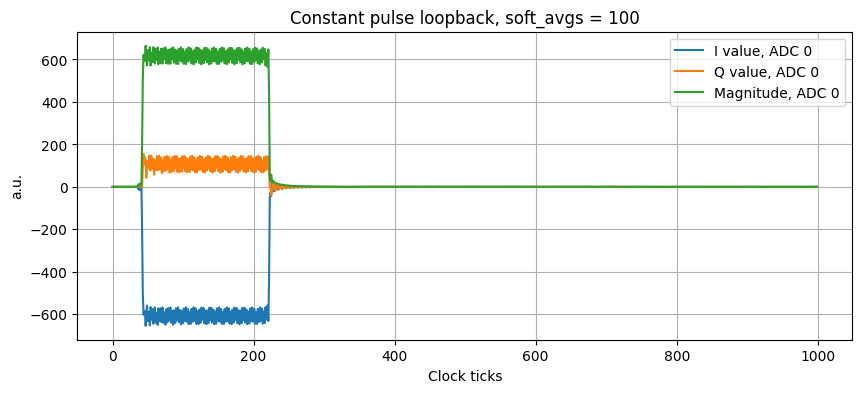

In [5]:
# Plot received ADC data.
plt.figure(figsize=(10, 4))
for ii, iq in enumerate(iq_list):
    I = iq[0]
    Q = iq[1]
    mag = np.abs(I + 1j*Q)

    plt.plot(I, label=f"I value, ADC {config['ro_chs'][ii]}")
    plt.plot(Q, label=f"Q value, ADC {config['ro_chs'][ii]}")
    plt.plot(mag, label=f"Magnitude, ADC {config['ro_chs'][ii]}")

plt.ylabel("a.u.")
plt.xlabel("Clock ticks")
plt.title("Constant pulse loopback, soft_avgs = " + str(config["soft_avgs"]))
plt.legend()
plt.grid(True)
plt.show()

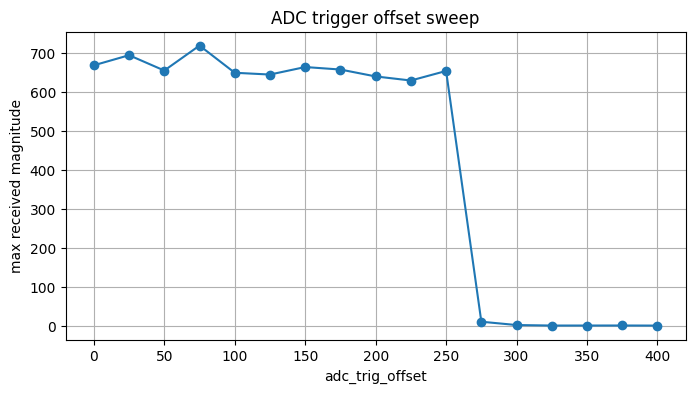

Best offset: 75


In [6]:
# Optional: sweep adc_trig_offset to find where the pulse lands in the ADC window.
offsets = list(range(0, 401, 25))
peak_mags = []

for offset in offsets:
    config["adc_trig_offset"] = offset
    prog = LoopbackProgram(soccfg, config)
    iq_list = prog.acquire_decimated(soc, progress=False)
    iq = iq_list[0]
    mag = np.abs(iq[0] + 1j*iq[1])
    peak_mags.append(np.max(mag))

plt.figure(figsize=(8, 4))
plt.plot(offsets, peak_mags, marker="o")
plt.xlabel("adc_trig_offset")
plt.ylabel("max received magnitude")
plt.title("ADC trigger offset sweep")
plt.grid(True)
plt.show()

# Put this back to the best-looking offset from the sweep.
best_offset = offsets[int(np.argmax(peak_mags))]
print("Best offset:", best_offset)
config["adc_trig_offset"] = best_offset

In [7]:
base = Path('.')
real_data = np.load(base /'adc_recovered_50k.npy', allow_pickle=False)
print("data shape:", real_data.shape)
print("data dtype:", real_data.dtype)

data shape: (50000, 6160)
data dtype: float64


In [8]:
class RealWaveformLoopbackProgram(AveragerProgram):
    def initialize(self):
        cfg = self.cfg
        res_ch = cfg["res_ch"]

        # Declare DAC channel
        self.declare_gen(ch=res_ch, nqz=cfg.get("nqz", 1))

        # Declare ADC readout
        for ch in cfg["ro_chs"]:
            self.declare_readout(
                ch=ch,
                length=cfg["readout_length"],
                freq=cfg["pulse_freq"],
                gen_ch=res_ch
            )

        # -----------------------------
        # REAL WAVEFORM HANDLING
        # -----------------------------
        real = np.asarray(cfg["real_data"], dtype=float)

        # DC remove (important for RF baseline stability)
        real = real - np.mean(real)

        # Normalize to DAC range
        max_abs = np.max(np.abs(real))
        if max_abs == 0:
            raise ValueError("Waveform is all zeros")

        real_norm = real / max_abs
        real_data = np.round(cfg.get("scale", 10000) * real_norm).astype(np.int16)

        # Ensure alignment to hardware constraints
        make_mult = cfg.get("make_mult", 16)
        n_trim = (len(real_data) // make_mult) * make_mult
        real_data = real_data[:n_trim]

        self.real_data = real_data

        # -----------------------------
        # UPLOAD WAVEFORM
        # -----------------------------
        # Try true real-arb first (if supported)
        try:
            self.add_pulse(
                ch=res_ch,
                name="real_waveform",
                style="arb",
                waveform=real_data
            )
            self.use_iq_fallback = False

        except Exception:
            # fallback: fake IQ (works on most QICK builds)
            self.use_iq_fallback = True
            self.add_pulse(
                ch=res_ch,
                name="real_waveform",
                style="arb",
                idata=real_data,
                qdata=np.zeros_like(real_data)
            )

        # Convert registers
        freq = self.freq2reg(cfg["pulse_freq"], gen_ch=res_ch, ro_ch=cfg["ro_chs"][0])
        phase = self.deg2reg(cfg["res_phase"], gen_ch=res_ch)
        gain = cfg["pulse_gain"]

        self.set_pulse_registers(
            ch=res_ch,
            style="arb",
            freq=freq,
            phase=phase,
            gain=gain,
            waveform="real_waveform"
        )

        self.synci(200)

    def body(self):
        self.measure(
            pulse_ch=self.cfg["res_ch"],
            adcs=self.ro_chs,
            pins=[0],
            adc_trig_offset=self.cfg["adc_trig_offset"],
            wait=True,
            syncdelay=self.us2cycles(self.cfg["relax_delay"])
        )

In [10]:
waveform_index = 0
start_location = 0
end_window = 6160

# Use the dataset loaded in cell 7.
waveform = np.asarray(real_data)
if waveform.ndim > 1:
    waveform = waveform[waveform_index, start_location:end_window]
else:
    waveform = waveform[start_location:end_window]

config_real = {
    "res_ch": GEN_CH,
    "ro_chs": [RO_CH],

    "nqz": 1,
    "reps": 1,
    "soft_avgs": 100,

    "relax_delay": 1.0,
    "readout_length": 1000,
    "adc_trig_offset": best_offset,

    "pulse_freq": 100,
    "pulse_gain": 10,
    "res_phase": 0,

    # NEW:
    "real_data": waveform,
    "scale": 10000,
    "make_mult": 16
}

prog = RealWaveformLoopbackProgram(soccfg, config_real)
iq_list = prog.acquire_decimated(soc, progress=False)

TypeError: QickProgram.add_pulse() got an unexpected keyword argument 'style'